# 1. Environment Setup and Tensor Basics

This section verifies the PyTorch environment, selects the available computing device, and demonstrates basic tensor operations.

**Objectives**
- Import the libraries used in the lab.
- Check the installed PyTorch and CUDA versions.
- Select CPU or GPU.
- Verify basic tensor operations.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Using CPU.")


Libraries imported successfully.
PyTorch version: 2.11.0+cpu
CUDA version: None
CUDA available: False
Selected device: cpu
GPU is not available. Using CPU.


## Tensor demonstration

A tensor is the main data structure in PyTorch. It can represent vectors, matrices, images, and other numerical data. The following example verifies shape, data type, arithmetic operations, matrix multiplication, and device transfer.


In [2]:
x = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
])

y = torch.ones((2, 2))

print("Tensor x:\n", x)
print("\nTensor y:\n", y)
print("\nShape:", x.shape)
print("Data type:", x.dtype)
print("\nAddition:\n", x + y)
print("\nElement-wise multiplication:\n", x * y)
print("\nMatrix multiplication:\n", x @ y)

x = x.to(device)
print("\nTensor device:", x.device)


Tensor x:
 tensor([[1., 2.],
        [3., 4.]])

Tensor y:
 tensor([[1., 1.],
        [1., 1.]])

Shape: torch.Size([2, 2])
Data type: torch.float32

Addition:
 tensor([[2., 3.],
        [4., 5.]])

Element-wise multiplication:
 tensor([[1., 2.],
        [3., 4.]])

Matrix multiplication:
 tensor([[3., 3.],
        [7., 7.]])

Tensor device: cpu


# FashionMNIST Dataset

In this section, the FashionMNIST dataset is loaded and prepared
for the image classification task.

FashionMNIST contains grayscale images of clothing items belonging
to 10 different classes. The dataset is divided into a training set
and a test set.

The dataset is loaded directly using
`torchvision.datasets.FashionMNIST`.


In [3]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys

print("Python executable:")
print(sys.executable)
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("PyTorch imported successfully!")
current_dir = Path.cwd()

if (current_dir / "Practice_1").exists():
    REPO_ROOT = current_dir
elif current_dir.name == "notebooks":
    REPO_ROOT = current_dir.parents[1]
else:
    REPO_ROOT = current_dir

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "Practice_1" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Dataset directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Python executable:
C:\Users\QUY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
PyTorch imported successfully!
Repository root: q:\Học sâu\UTH-Deep-Learning-nhom2
Dataset directory: q:\Học sâu\UTH-Deep-Learning-nhom2\data
Figure directory: q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\figures


## Data Transformation

Before the images are used by the neural network, they are converted
to PyTorch tensors using `transforms.ToTensor()`.

This transformation converts the image data into a tensor representation
that can be processed by PyTorch.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

print(transform)
# Use the official FashionMNIST GitHub repository as a download mirror
datasets.FashionMNIST.mirrors = [
    "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
]

print("FashionMNIST mirror updated.")
train_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform
)

print("FashionMNIST loaded successfully!")
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

image, label = train_dataset[0]

print("\nFirst sample")
print("Image shape:", image.shape)
print("Label:", label)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Compose(
    ToTensor()
)
FashionMNIST mirror updated.
FashionMNIST loaded successfully!
Number of training samples: 60000
Number of test samples: 10000

First sample
Image shape: torch.Size([1, 28, 28])
Label: 9
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Observation

The dataset was loaded successfully.

Each image is represented as a PyTorch tensor with one grayscale
channel. The image dimensions are suitable for use as input to the
neural network.

After `ToTensor()`, the image values are represented as floating-point
values suitable for PyTorch computations.

In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


## Creating DataLoaders

PyTorch `DataLoader` is used to divide the dataset into mini-batches.

For the training dataset, `shuffle=True` is used so that the samples
are presented in a different order during training.

For the test dataset, `shuffle=False` is used because the test set
is only used for model evaluation.

In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training DataLoader created.")
print("Test DataLoader created.")
print("Batch size:", BATCH_SIZE)
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training DataLoader created.
Test DataLoader created.
Batch size: 64
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


### Batch Inspection

A mini-batch was extracted from the training DataLoader to verify
the data structure.

The image tensor follows the format:

`[batch_size, channels, height, width]`

The label tensor contains the class labels corresponding to the
images in the batch.

Mini-batch training allows the neural network to process a subset
of the training data during each optimization step.

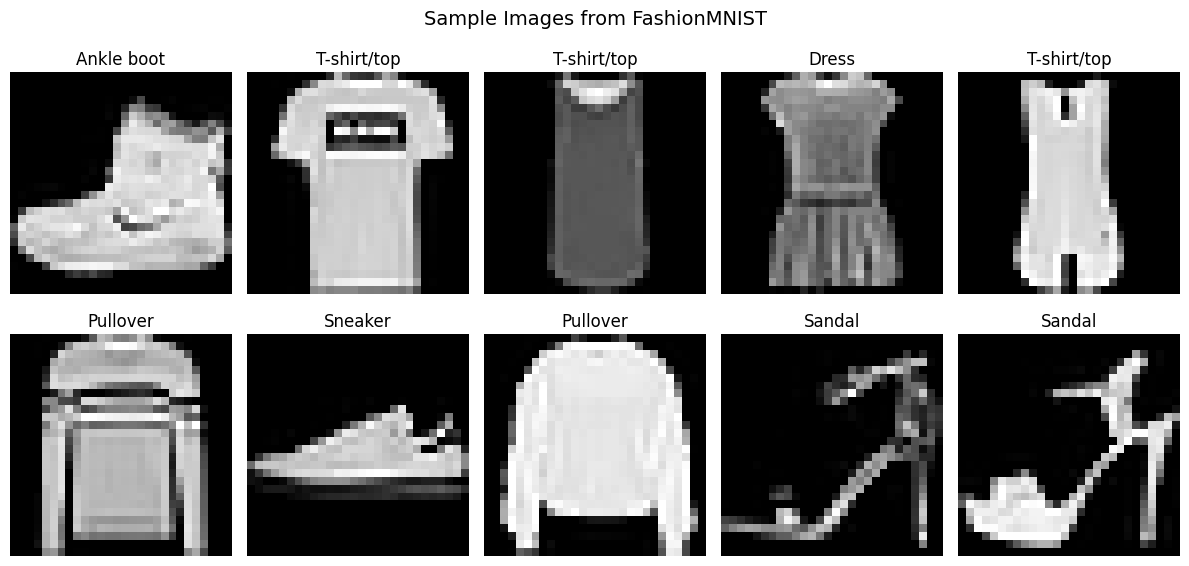

Figure saved to: q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\figures\dataset_samples.png


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle(
    "Sample Images from FashionMNIST",
    fontsize=14
)

plt.tight_layout()

output_path = FIGURE_DIR / "dataset_samples.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_path)

##  DataLoader

PyTorch `DataLoader` is used to divide the dataset into mini-batches
for efficient neural network training.

For the training dataset, `shuffle=True` is used to shuffle the samples
before each training epoch.

For the test dataset, `shuffle=False` is used because the test data
is only used for model evaluation.

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train DataLoader created successfully.")
print("Test DataLoader created successfully.")
print("Batch size:", BATCH_SIZE)
print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))
images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
for i in range(10):
    label_index = labels[i].item()
    print(
        f"Sample {i + 1}: "
        f"Label = {label_index}, "
        f"Class = {class_names[label_index]}"
    )

Train DataLoader created successfully.
Test DataLoader created successfully.
Batch size: 64
Number of training batches: 938
Number of test batches: 157
Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Sample 1: Label = 6, Class = Shirt
Sample 2: Label = 1, Class = Trouser
Sample 3: Label = 0, Class = T-shirt/top
Sample 4: Label = 1, Class = Trouser
Sample 5: Label = 5, Class = Sandal
Sample 6: Label = 8, Class = Bag
Sample 7: Label = 7, Class = Sneaker
Sample 8: Label = 3, Class = Dress
Sample 9: Label = 3, Class = Dress
Sample 10: Label = 0, Class = T-shirt/top


##  Mo ta MLP - Kien truc `784 -> 128 -> 64 -> 10`

```
28 x 28 image
      |
   Flatten
      |
     784
      |
    Linear
      |
     128
      |
     ReLU
      |
    Linear
      |
     64
      |
     ReLU
      |
    Linear
      |
  10 outputs (logits)
```

- **Input Layer**: anh dau vao `28 x 28 x 1` (grayscale). `Flatten`
  chuyen anh 2 chieu thanh vector 1 chieu `784` gia tri.
- **Hidden Layer**: 2 lop an fully-connected, `Linear(784, 128)` roi
  `Linear(128, 64)`, hoc cach to hop cac dac trung tu lop truoc.
- **Activation Function**: `ReLU` (`max(0, x)`) sau moi lop an. Neu
  khong co ReLU, nhieu lop `Linear` xep chong nhau ve mat toan hoc chi
  tuong duong 1 phep bien doi tuyen tinh duy nhat, mang se khong hoc
  duoc quan he phi tuyen trong du lieu.
- **Output Layer**: `Linear(64, 10)` tra ve **10 logits**, moi gia tri
  ung voi mot lop trang phuc trong FashionMNIST. Khong dung `Softmax`
  o day (xem giai thich chi tiet o muc 8).


In [9]:
from pathlib import Path
import sys
import torch


def find_repo_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for current_path in [start_path, *start_path.parents]:
        if (current_path / "Practice_1").is_dir():
            return current_path

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc chứa Practice_1."
    )


REPO_ROOT = find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Practice_1.src.model import NeuralNetwork

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Import NeuralNetwork thành công.")
print("Device:", device)

Import NeuralNetwork thành công.
Device: cpu


##  Khoi tao model 
##  In model architecture

In [10]:
model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


##  Kiem tra input shape

Lay 1 batch anh that tu `train_loader` de kiem tra shape dau vao, va
shape sau khi qua `Flatten`.
## Kiem tra output shape

Dua ca batch qua toan bo model, output phai co shape `[batch, 10]`.



In [11]:
images, labels = next(iter(train_loader))

print("Input shape (truoc Flatten):", images.shape)  # [batch, 1, 28, 28]

flattened = model.flatten(images.to(device))
print("Shape sau Flatten:", flattened.shape)   
images = images.to(device)

with torch.no_grad():
    logits = model(images)

print("Output shape:", logits.shape)  # [batch, 10]
print("Logits cua anh dau tien:\n", logits[0])
       # [batch, 784]


Input shape (truoc Flatten): torch.Size([64, 1, 28, 28])
Shape sau Flatten: torch.Size([64, 784])
Output shape: torch.Size([64, 10])
Logits cua anh dau tien:
 tensor([-0.1124,  0.1995,  0.1148, -0.0310, -0.0249,  0.0403,  0.0583,  0.0984,
        -0.0661,  0.0295])


##  Dem trainable parameters

In [12]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


total_params = count_trainable_parameters(model)
print(f"Tong so trainable parameters: {total_params:,}")

for name, param in model.named_parameters():
    print(f"{name:20s} {str(tuple(param.shape)):15s} {param.numel():,} params")
# Minh hoa: argmax tren logits va argmax tren xac suat (sau softmax)
# cho ket qua giong nhau, vi Softmax la phep bien doi don dieu.
probs = torch.softmax(logits, dim=1)

pred_from_logits = torch.argmax(logits, dim=1)
pred_from_probs = torch.argmax(probs, dim=1)

print("Du doan giong nhau:", torch.equal(pred_from_logits, pred_from_probs))
print("Lop du doan (10 anh dau):",
      [class_names[i] for i in pred_from_logits[:10].tolist()])



Tong so trainable parameters: 109,386
network.0.weight     (128, 784)      100,352 params
network.0.bias       (128,)          128 params
network.2.weight     (64, 128)       8,192 params
network.2.bias       (64,)           64 params
network.4.weight     (10, 64)        640 params
network.4.bias       (10,)           10 params
Du doan giong nhau: True
Lop du doan (10 anh dau): ['Trouser', 'Trouser', 'Trouser', 'Trouser', 'Trouser', 'Trouser', 'Trouser', 'Trouser', 'Sneaker', 'Sneaker']


## Ham save model

Luu `state_dict` (trong so) cua model ra file `.pth`.
##  Ham load model

Khoi tao lai mot instance `NeuralNetwork` moi va nap trong so da luu
vao. `model.eval()` chuyen model sang che do danh gia.



In [13]:
def save_model(model: nn.Module, path: str = "fashion_mnist.pth") -> None:
    torch.save(model.state_dict(), path)
    print(f"Model da duoc luu vao: {path}")


save_model(model)
def load_model(path: str = "fashion_mnist.pth",
                device: torch.device = device) -> NeuralNetwork:
    loaded_model = NeuralNetwork().to(device)
    loaded_model.load_state_dict(torch.load(path, map_location=device))
    loaded_model.eval()
    return loaded_model


loaded_model = load_model()
print("Model da duoc load thanh cong.")
print(loaded_model)
# Kiem tra: model sau khi load cho ket qua giong het model truoc khi save
with torch.no_grad():
    original_logits = model(images)
    loaded_logits = loaded_model(images)

print("Output giong nhau sau khi load lai:",
      torch.allclose(original_logits, loaded_logits))
images, labels = next(iter(train_loader))
outputs = model(images)

print(outputs.shape)


Model da duoc luu vao: fashion_mnist.pth
Model da duoc load thanh cong.
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Output giong nhau sau khi load lai: True
torch.Size([64, 10])


# 4. Model Training — FashionMNIST MLP

**Practice 1: FashionMNIST Classification with PyTorch**

sử dụng `data.py` của Thành viên 2 và `model.py`  

## 4.1. Training workflow

Quy trình huấn luyện cho mỗi batch:

`Load batch → Move to device → zero_grad() → Forward → Loss → Backward → optimizer.step()`

- `Forward`: mô hình tạo logits cho 10 lớp FashionMNIST.
- `Loss`: `CrossEntropyLoss` đo sai lệch giữa logits và nhãn thật.
- `Backward`: Autograd tính gradient.
- `optimizer.step()`: Adam cập nhật trọng số mô hình.


In [14]:
from Practice_1.src.model import NeuralNetwork

test_model = NeuralNetwork()

print(test_model)
import importlib
import Practice_1.src.model as model_module

importlib.reload(model_module)

NeuralNetwork = model_module.NeuralNetwork

model = NeuralNetwork()

print("Import model thành công!")
print(model)
from pathlib import Path
import csv
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


def find_repo_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa Practice_1."""
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "Practice_1").is_dir():
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc repository chứa Practice_1. "
        "Hãy mở notebook từ repository UTH-Deep-Learning-nhom2."
    )


REPO_ROOT = find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from Practice_1.src.data import create_dataloaders
except (ImportError, ModuleNotFoundError) as exc:
    raise ImportError(
        "Không import được create_dataloaders từ Practice_1/src/data.py. "
        "Hãy kiểm tra phần Thành viên 2."
    ) from exc

try:
    from Practice_1.src.model import NeuralNetwork
except (ImportError, ModuleNotFoundError) as exc:
    raise ImportError(
        "Không import được NeuralNetwork từ Practice_1/src/model.py. "
        "Hãy kiểm tra phần Thành viên 3."
    ) from exc

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "Practice_1" / "figures"
MODEL_DIR = REPO_ROOT / "Practice_1" / "models"
EXPERIMENT_DIR = REPO_ROOT / "Practice_1" / "experiments"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root :", REPO_ROOT)
print("Data directory  :", DATA_DIR)
print("Figure directory:", FIGURE_DIR)
print("Model directory :", MODEL_DIR)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Import model thành công!
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Repository root : Q:\Học sâu\UTH-Deep-Learning-nhom2
Data directory  : Q:\Học sâu\UTH-Deep-Learning-nhom2\data
Figure directory: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\figures
Model directory : Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\models


## 4.2. Configuration and reproducibility

Cấu hình baseline của nhóm:

- Batch size: `64`
- Learning rate: `0.001`
- Optimizer: `Adam`
- Number of epochs: `10`
- Loss function: `CrossEntropyLoss`


In [15]:
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device        :", device)
print("Batch size    :", BATCH_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Epochs        :", NUM_EPOCHS)


Device        : cpu
Batch size    : 64
Learning rate : 0.001
Epochs        : 10


## 4.3. Load FashionMNIST DataLoaders

Dữ liệu được lấy từ hàm dùng chung của Thành viên 2. TV4 không tải lại dữ liệu bằng một đoạn code độc lập để tránh sai khác về transform, batch size và đường dẫn.


## 4.4. Initialize the MLP model

Mô hình được import từ `Practice_1/src/model.py` của Thành viên 3. Kiến trúc dùng để huấn luyện và kiến trúc dùng để load checkpoint ở Thành viên 5 phải giống hoàn toàn.


In [16]:
(
    train_dataset,
    test_dataset,
    train_loader,
    test_loader,
) = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
)

images, labels = next(iter(train_loader))

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print("Training batches :", len(train_loader))
print("Test batches     :", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

assert images.ndim == 4, "Batch ảnh phải có 4 chiều."
assert images.shape[1:] == (1, 28, 28), "FashionMNIST phải có shape [N, 1, 28, 28]."
assert labels.ndim == 1, "Nhãn phải có shape [N]."
model = NeuralNetwork().to(device)

with torch.no_grad():
    sample_logits = model(images.to(device))

print(model)
print("Input shape :", images.shape)
print("Output shape:", sample_logits.shape)

assert sample_logits.shape == (images.shape[0], 10), (
    "Output của mô hình phải có shape [batch_size, 10]."
)



Training samples : 60000
Test samples     : 10000
Training batches : 938
Test batches     : 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Input shape : torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


## 4.5. Loss function and optimizer

- `CrossEntropyLoss` nhận trực tiếp logits và nhãn số nguyên từ `0` đến `9`.
- Không đặt `Softmax` trong lớp cuối của mô hình.
- Adam được dùng với learning rate `0.001` làm cấu hình baseline.
## 4.6. Training function

Hàm dưới đây trả về lịch sử:

- `train_loss`: loss trung bình trên toàn bộ mẫu huấn luyện của mỗi epoch.
- `train_accuracy`: tỷ lệ dự đoán đúng trên tập huấn luyện của mỗi epoch.
- `epoch_time`: thời gian chạy của từng epoch.



In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print("Loss function:", criterion)
print("Optimizer    :", optimizer.__class__.__name__)
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
):
    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "epoch_time": [],
    }

    total_start = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total
        epoch_time = time.perf_counter() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss)
        history["train_accuracy"].append(epoch_accuracy)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch:02d}/{num_epochs}] "
            f"- Loss: {epoch_loss:.4f} "
            f"- Train Accuracy: {epoch_accuracy:.2f}% "
            f"- Time: {epoch_time:.2f}s"
        )

    total_time = time.perf_counter() - total_start
    print(f"\nTraining completed in {total_time:.2f} seconds.")

    return history, total_time



Loss function: CrossEntropyLoss()
Optimizer    : Adam


## 4.7. Run training

Sau khi chạy cell này, loss thường phải giảm dần. Kết quả cụ thể có thể khác giữa CPU, GPU và các lần chạy.


In [18]:
history, total_training_time = train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch [01/10] - Loss: 0.5512 - Train Accuracy: 80.72% - Time: 9.40s
Epoch [02/10] - Loss: 0.3899 - Train Accuracy: 86.16% - Time: 8.67s
Epoch [03/10] - Loss: 0.3499 - Train Accuracy: 87.20% - Time: 4.87s
Epoch [04/10] - Loss: 0.3265 - Train Accuracy: 87.90% - Time: 4.76s
Epoch [05/10] - Loss: 0.3053 - Train Accuracy: 88.83% - Time: 5.13s
Epoch [06/10] - Loss: 0.2912 - Train Accuracy: 89.08% - Time: 4.53s
Epoch [07/10] - Loss: 0.2769 - Train Accuracy: 89.83% - Time: 9.89s
Epoch [08/10] - Loss: 0.2670 - Train Accuracy: 89.98% - Time: 8.80s
Epoch [09/10] - Loss: 0.2564 - Train Accuracy: 90.40% - Time: 8.92s
Epoch [10/10] - Loss: 0.2460 - Train Accuracy: 90.85% - Time: 5.96s

Training completed in 70.93 seconds.


## 4.8. Save training history

Lịch sử huấn luyện được lưu thành CSV để nhóm trưởng và Thành viên 6 có thể dùng khi làm báo cáo hoặc so sánh hyperparameter.
## 4.9. Plot and save training loss

Biểu đồ loss là một sản phẩm bắt buộc của Practice 1. Đường loss giảm cho thấy quá trình tối ưu đang cải thiện mô hình trên tập huấn luyện.
## 4.10. Plot training accuracy

Training accuracy giúp kiểm tra mô hình có học trên tập train hay không. Đây không phải test accuracy; việc đánh giá trên tập test thuộc phần Thành viên 5.




Saved training history: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\experiments\tv4_training_history.csv


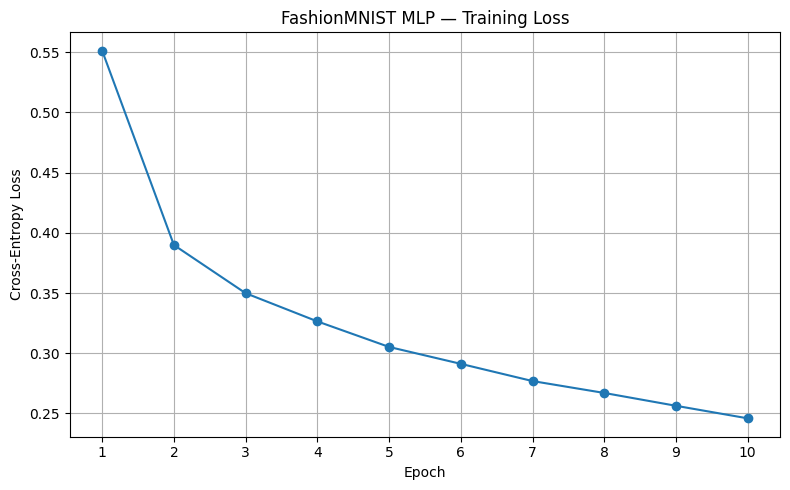

Saved loss graph: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\figures\training_loss.png


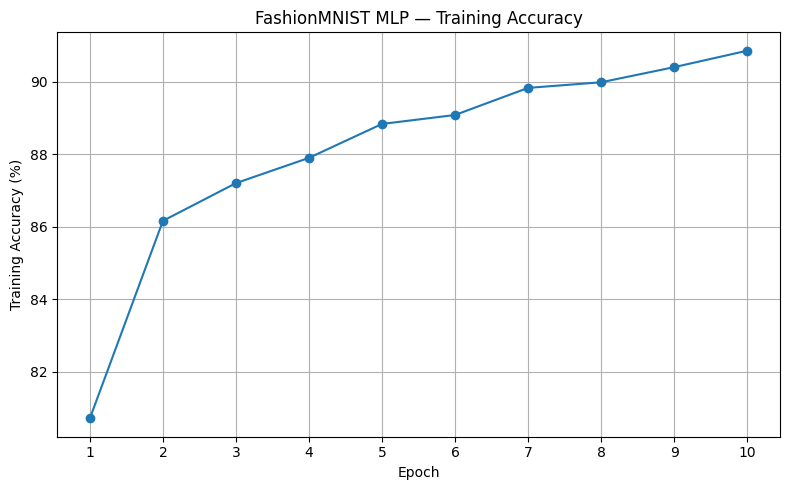

Saved accuracy graph: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\figures\training_accuracy.png


In [19]:
HISTORY_PATH = EXPERIMENT_DIR / "tv4_training_history.csv"

with HISTORY_PATH.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "epoch",
        "train_loss",
        "train_accuracy",
        "epoch_time_seconds",
    ])

    for epoch, loss, accuracy, epoch_time in zip(
        history["epoch"],
        history["train_loss"],
        history["train_accuracy"],
        history["epoch_time"],
    ):
        writer.writerow([
            epoch,
            f"{loss:.6f}",
            f"{accuracy:.4f}",
            f"{epoch_time:.4f}",
        ])

print("Saved training history:", HISTORY_PATH)
LOSS_FIGURE_PATH = FIGURE_DIR / "training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved loss graph:", LOSS_FIGURE_PATH)
ACCURACY_FIGURE_PATH = FIGURE_DIR / "training_accuracy.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_accuracy"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved accuracy graph:", ACCURACY_FIGURE_PATH)




## 4.11. Save the trained model

Checkpoint được lưu **sau khi huấn luyện**. Thành viên 5 dùng đúng file này để tính test loss, test accuracy và hiển thị dự đoán.
## 4.12. Verify save/load

Cell này kiểm tra checkpoint có thể load lại bằng đúng kiến trúc `NeuralNetwork`. Hai mô hình phải tạo logits giống nhau trên cùng một batch.
## 4.13. Training result analysis

Sau khi chạy notebook, cần nhận xét:

1. Loss ở epoch đầu và epoch cuối.
2. Loss có giảm đều hay dao động mạnh.
3. Training accuracy có tăng hay không.
4. Thời gian huấn luyện.
5. Chưa kết luận khả năng tổng quát hóa chỉ từ training loss; cần kết quả test của Thành viên 5.


In [20]:
MODEL_PATH = MODEL_DIR / "fashion_mnist_mlp_trained.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH,
)

print("Saved trained model:", MODEL_PATH)
print("Checkpoint size (KB):", MODEL_PATH.stat().st_size / 1024)
reloaded_model = NeuralNetwork().to(device)

state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

reloaded_model.load_state_dict(state_dict)
reloaded_model.eval()
model.eval()

verification_images, _ = next(iter(train_loader))
verification_images = verification_images.to(device)

with torch.no_grad():
    original_logits = model(verification_images)
    reloaded_logits = reloaded_model(verification_images)

same_outputs = torch.allclose(
    original_logits,
    reloaded_logits,
    atol=1e-6,
)

print("Checkpoint loaded successfully:", same_outputs)
assert same_outputs, "Output sau khi load checkpoint không khớp model đã lưu."
first_loss = history["train_loss"][0]
final_loss = history["train_loss"][-1]
loss_reduction = first_loss - final_loss

first_accuracy = history["train_accuracy"][0]
final_accuracy = history["train_accuracy"][-1]

print("TRAINING SUMMARY")
print("-" * 50)
print(f"First epoch loss       : {first_loss:.4f}")
print(f"Final epoch loss       : {final_loss:.4f}")
print(f"Loss reduction         : {loss_reduction:.4f}")
print(f"First train accuracy   : {first_accuracy:.2f}%")
print(f"Final train accuracy   : {final_accuracy:.2f}%")
print(f"Total training time    : {total_training_time:.2f}s")
print(f"Saved checkpoint       : {MODEL_PATH.name}")
print(f"Saved loss figure      : {LOSS_FIGURE_PATH.name}")


Saved trained model: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
Checkpoint size (KB): 430.0205078125
Checkpoint loaded successfully: True
TRAINING SUMMARY
--------------------------------------------------
First epoch loss       : 0.5512
Final epoch loss       : 0.2460
Loss reduction         : 0.3052
First train accuracy   : 80.72%
Final train accuracy   : 90.85%
Total training time    : 70.93s
Saved checkpoint       : fashion_mnist_mlp_trained.pth
Saved loss figure      : training_loss.png


# Import thư viện

In [21]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# 2. Xác định đường dẫn repository và checkpoint và đưa mô hình về chế độ eval

In [28]:
import sys
from pathlib import Path
import torch

# 1. Xác định thư mục gốc (Practice_1)
current_dir = Path.cwd()
REPO_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

# 2. Thêm REPO_ROOT vào sys.path để Python nhận diện được thư mục 'src'
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

# 3. Import từ thư mục src
from src.data import create_dataloaders, CLASS_NAMES
from src.model import NeuralNetwork

# 4. Khởi tạo Device & DataLoaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = REPO_ROOT / "data"

_, _, _, test_loader = create_dataloaders(data_dir=data_dir, batch_size=64)

# 5. Khởi tạo mô hình
model = NeuralNetwork().to(device)

# 6. Load Checkpoint
CHECKPOINT_PATH = REPO_ROOT / "models" / "fashion_mnist_mlp_trained.pth"

if CHECKPOINT_PATH.exists():
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(f"Load checkpoint thành công từ: {CHECKPOINT_PATH.resolve()}")
else:
    print(f"Không tìm thấy file checkpoint tại: {CHECKPOINT_PATH.resolve()}")

# 7. Đưa về chế độ đánh giá
model.eval()

Load checkpoint thành công từ: Q:\Học sâu\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

# 7. Tính Test Loss, Tính Test Accuracy, Lấy predicted labels


In [23]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
            all_confidences.extend(confidences.cpu().tolist())

    return {
        "test_loss": total_loss / total_samples,
        "test_accuracy": 100.0 * total_correct / total_samples,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "confidences": np.array(all_confidences),
    }

In [24]:
criterion = nn.CrossEntropyLoss()

evaluation = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("EVALUATION RESULT")
print("-" * 40)
print(f"Test Loss    : {evaluation['test_loss']:.4f}")
print(f"Test Accuracy: {evaluation['test_accuracy']:.2f}%")

EVALUATION RESULT
----------------------------------------
Test Loss    : 0.3336
Test Accuracy: 88.50%


In [25]:

criterion = nn.CrossEntropyLoss()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []
misclassified_images = []
misclassified_preds = []
misclassified_labels = []
correct_images = []
correct_preds = []

# Tắt tính toán gradient để tiết kiệm bộ nhớ và tăng tốc độ
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # Dự đoán
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Lưu kết quả
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Phân loại ảnh đúng/sai để vẽ đồ thị
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_preds.append(predicted[i].item())
                misclassified_labels.append(labels[i].item())
            else:
                correct_images.append(images[i].cpu())
                correct_preds.append(predicted[i].item())

# Tính trung bình Loss và phần trăm Accuracy
test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Tổng kết đánh giá trên tập Test:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Tổng kết đánh giá trên tập Test:
Test Loss: 0.3331
Test Accuracy: 88.50%


# 10. Hiển thị Predicted vs Actual (Các mẫu đoán đúng)

----------------------------------------
 THỐNG KÊ KẾT QUẢ DỰ ĐOÁN:
  - Tổng số mẫu đánh giá : 10000
  - Tổng số dự đoán ĐÚNG : 8850 (88.50%)
  - Tổng số dự đoán SAI  : 1150 (11.50%)
----------------------------------------



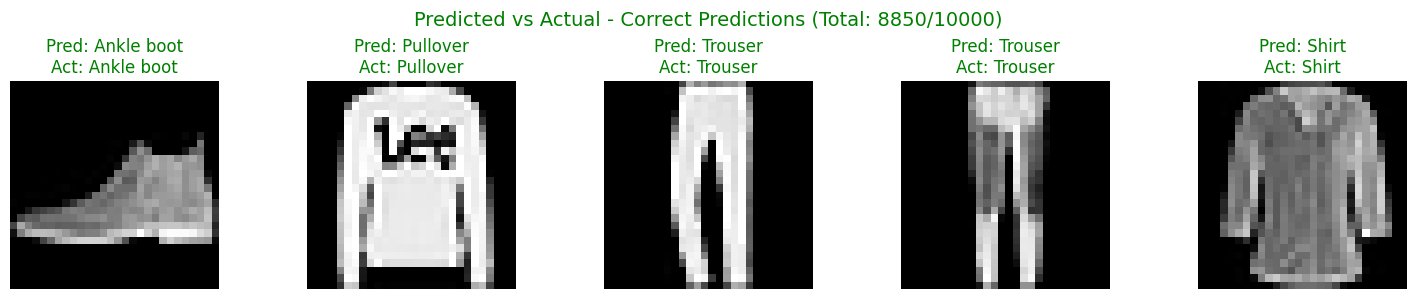

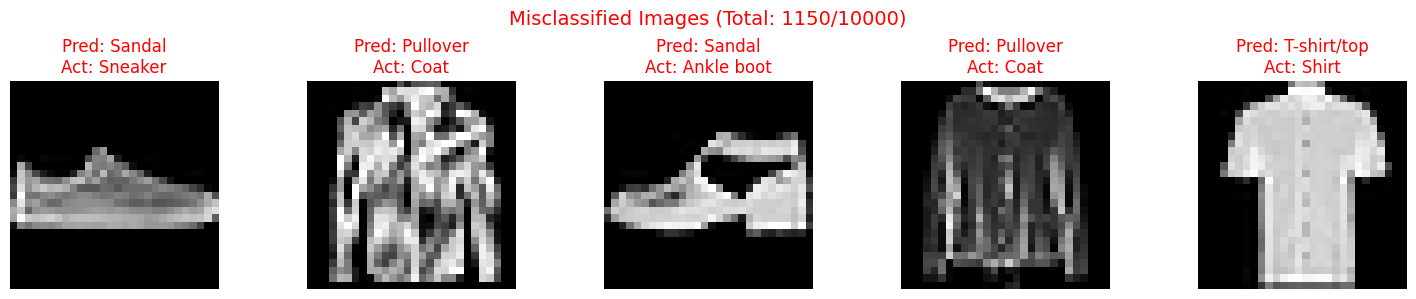

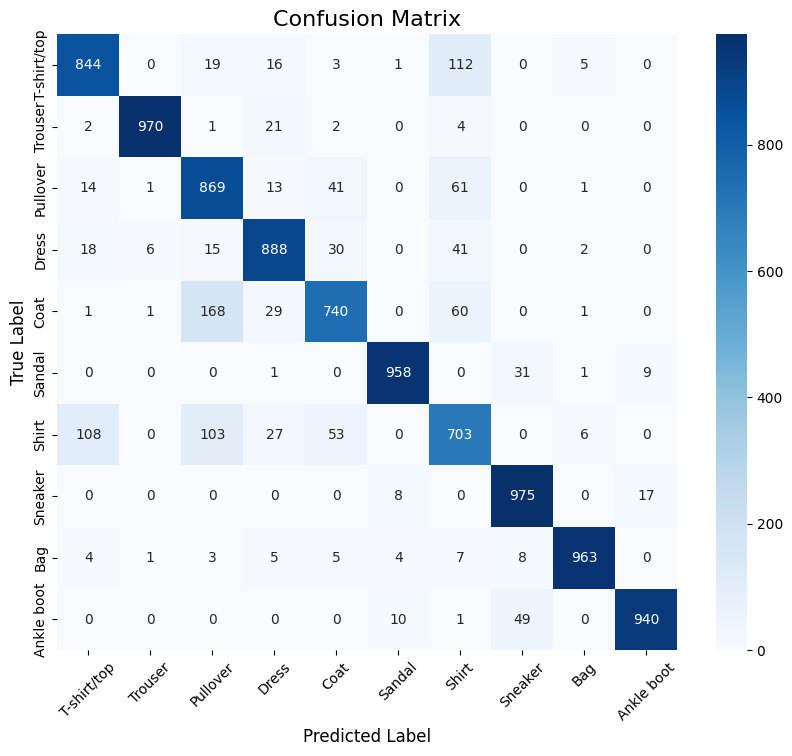

In [26]:
import numpy as np

# --- Tính toán tổng số lượng ---
total_correct = len(correct_images)
total_misclassified = len(misclassified_images)
total_samples = total_correct + total_misclassified
accuracy = (total_correct / total_samples) * 100

# In tóm tắt ra màn hình
print("-" * 40)
print(f" THỐNG KÊ KẾT QUẢ DỰ ĐOÁN:")
print(f"  - Tổng số mẫu đánh giá : {total_samples}")
print(f"  - Tổng số dự đoán ĐÚNG : {total_correct} ({accuracy:.2f}%)")
print(f"  - Tổng số dự đoán SAI  : {total_misclassified} ({100 - accuracy:.2f}%)")
print("-" * 40 + "\n")

# 10. Hiển thị một số dự đoán đúng (Kèm tổng số lượng trên tiêu đề)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Predicted vs Actual - Correct Predictions (Total: {total_correct}/{total_samples})', fontsize=14, color='green')
for i in range(min(5, total_correct)):
    ax = axes[i]
    ax.imshow(correct_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {class_names[correct_preds[i]]}\nAct: {class_names[correct_preds[i]]}", color="green")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 11. Hiển thị một số dự đoán sai (Kèm tổng số lượng trên tiêu đề)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Misclassified Images (Total: {total_misclassified}/{total_samples})', fontsize=14, color='red')
for i in range(min(5, total_misclassified)):
    ax = axes[i]
    ax.imshow(misclassified_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {class_names[misclassified_preds[i]]}\nAct: {class_names[misclassified_labels[i]]}", color="red")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 12. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.show()

14. Summary

Quá trình xây dựng một quy trình học sâu (Deep Learning pipeline) hoàn chỉnh đã được thực hiện: từ việc load dữ liệu FashionMNIST, tiền xử lý bằng DataLoader, xây dựng mạng NeuralNetwork, cho đến việc load trọng số và đánh giá.

Việc chuyển mô hình sang trạng thái model.eval() và vô hiệu hóa gradient torch.no_grad() là bước bắt buộc để đảm bảo tốc độ và tính toán chính xác trong khâu inference (suy luận).

Việc phân tích trực quan qua ảnh và ma trận nhầm lẫn giúp định hướng rõ ràng cho các bước tối ưu tiếp theo (chẳng hạn như đổi sang dùng kiến trúc CNN để cải thiện khả năng phân loại các item quần áo giống nhau).

14. Summary

Quá trình xây dựng một quy trình học sâu (Deep Learning pipeline) hoàn chỉnh đã được thực hiện: từ việc load dữ liệu FashionMNIST, tiền xử lý bằng DataLoader, xây dựng mạng NeuralNetwork, cho đến việc load trọng số và đánh giá.

Việc chuyển mô hình sang trạng thái model.eval() và vô hiệu hóa gradient torch.no_grad() là bước bắt buộc để đảm bảo tốc độ và tính toán chính xác trong khâu inference (suy luận).

Việc phân tích trực quan qua ảnh và ma trận nhầm lẫn giúp định hướng rõ ràng cho các bước tối ưu tiếp theo (chẳng hạn như đổi sang dùng kiến trúc CNN để cải thiện khả năng phân loại các item quần áo giống nhau).